In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parents[1]   # move up from notebooks/
sys.path.insert(0, str(PROJECT_ROOT))
from data import ESMCSingleDS
from models import SequenceActiveSiteHead
import torch
from plotting import hists
from pathlib import Path
from torch.utils.data import DataLoader
from data import pad_collate_fn

In [2]:
data_name = 'IEDB_Jespersen'
model_name = 'esmc_300m'
base_data_dir = Path.cwd().parents[1]/'proteins'  / 'data'/ 'data_files'
dataset = ESMCSingleDS(data_name, model_name, save_dir=base_data_dir, max_len=3000)

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.mps.is_available() else 'cpu')

train_loader = DataLoader(dataset, batch_size=200, shuffle=True, collate_fn=pad_collate_fn)

def apply_mask(x, mask):
    f = x.shape[-1]
    x, mask = x.reshape(-1, f), mask.reshape(-1)
    return x[mask]
inputs, y, mask = next(iter(train_loader))
inputs = inputs.to(device)
y = y.to(device)
mask = mask.to(device)


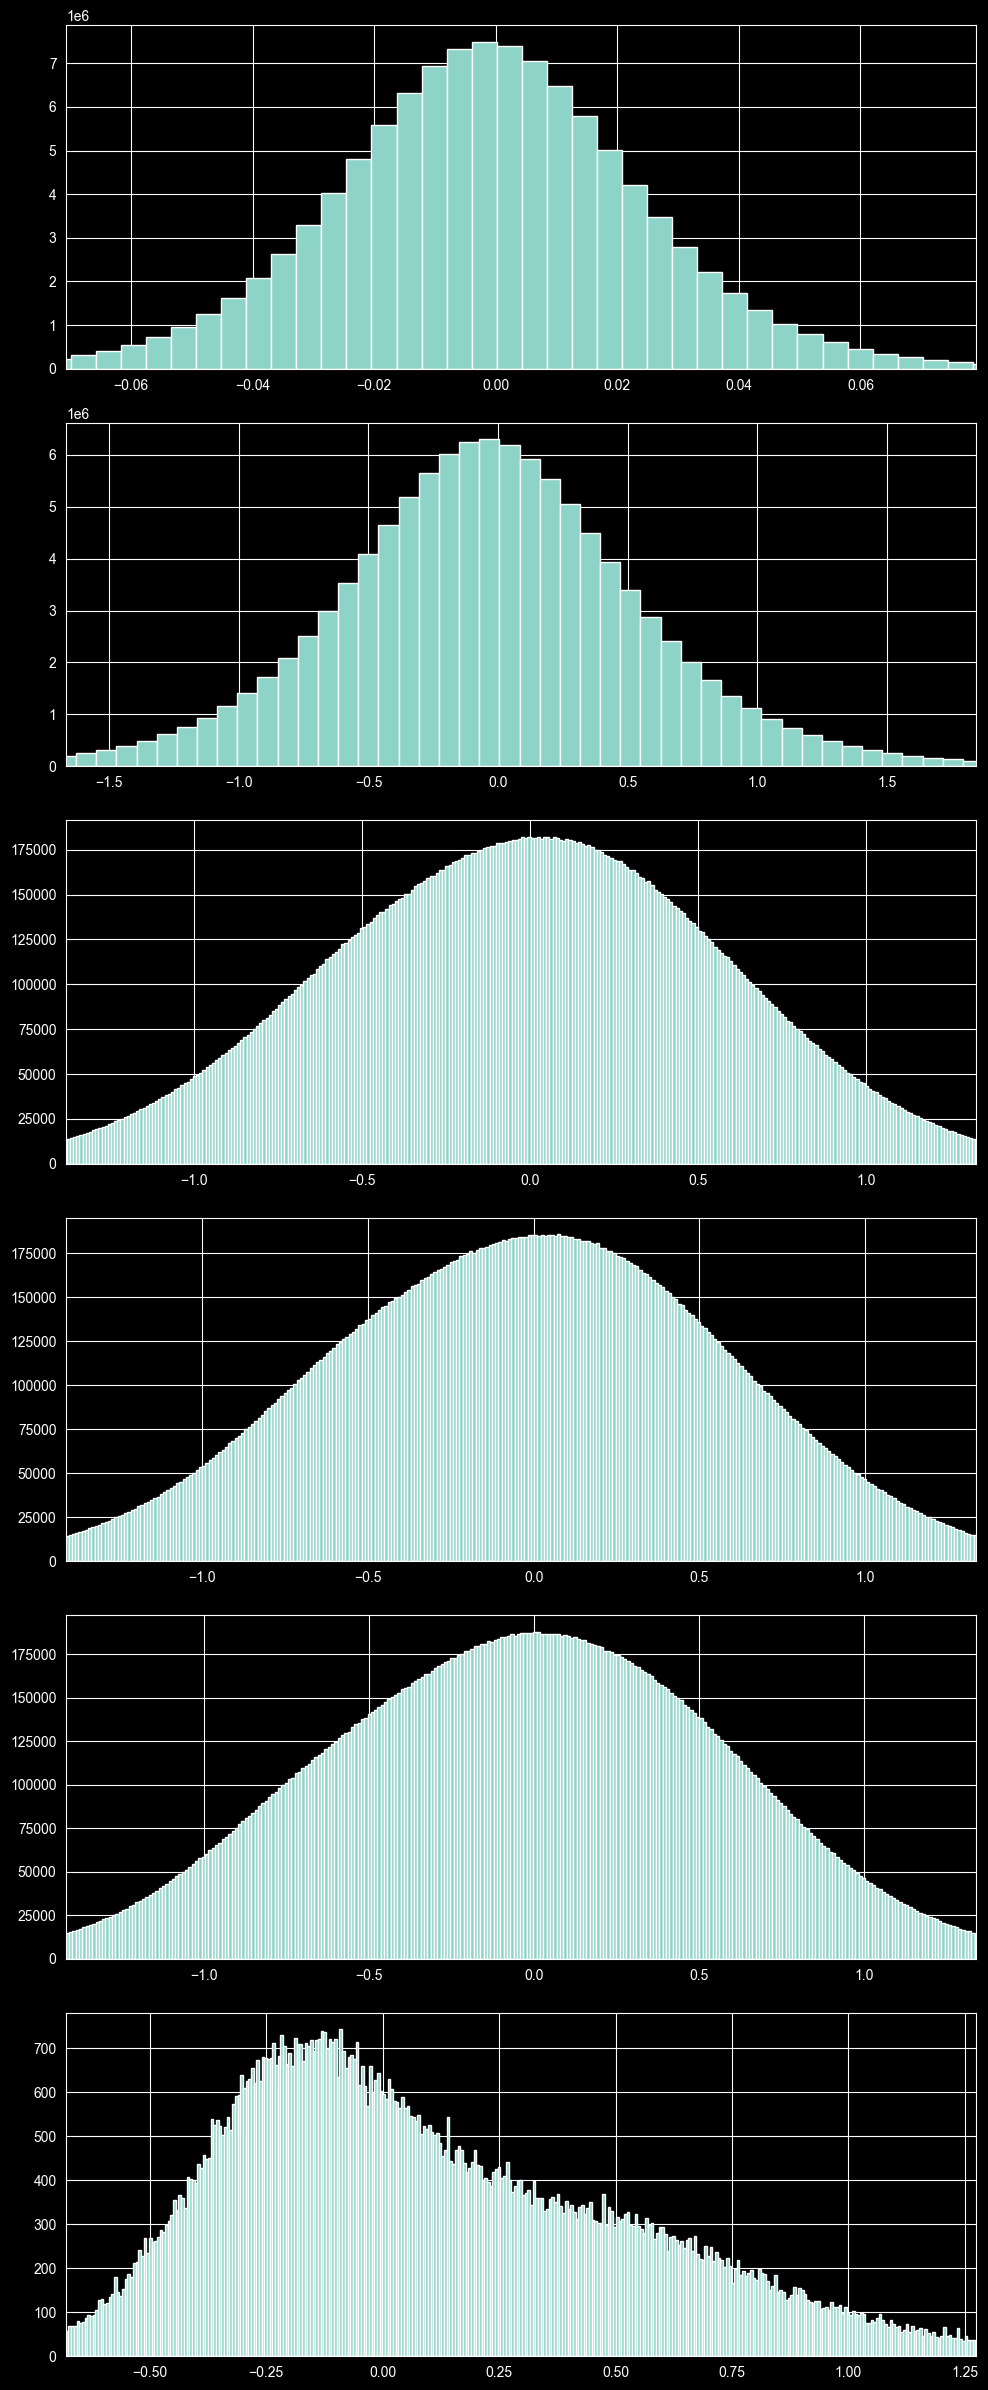

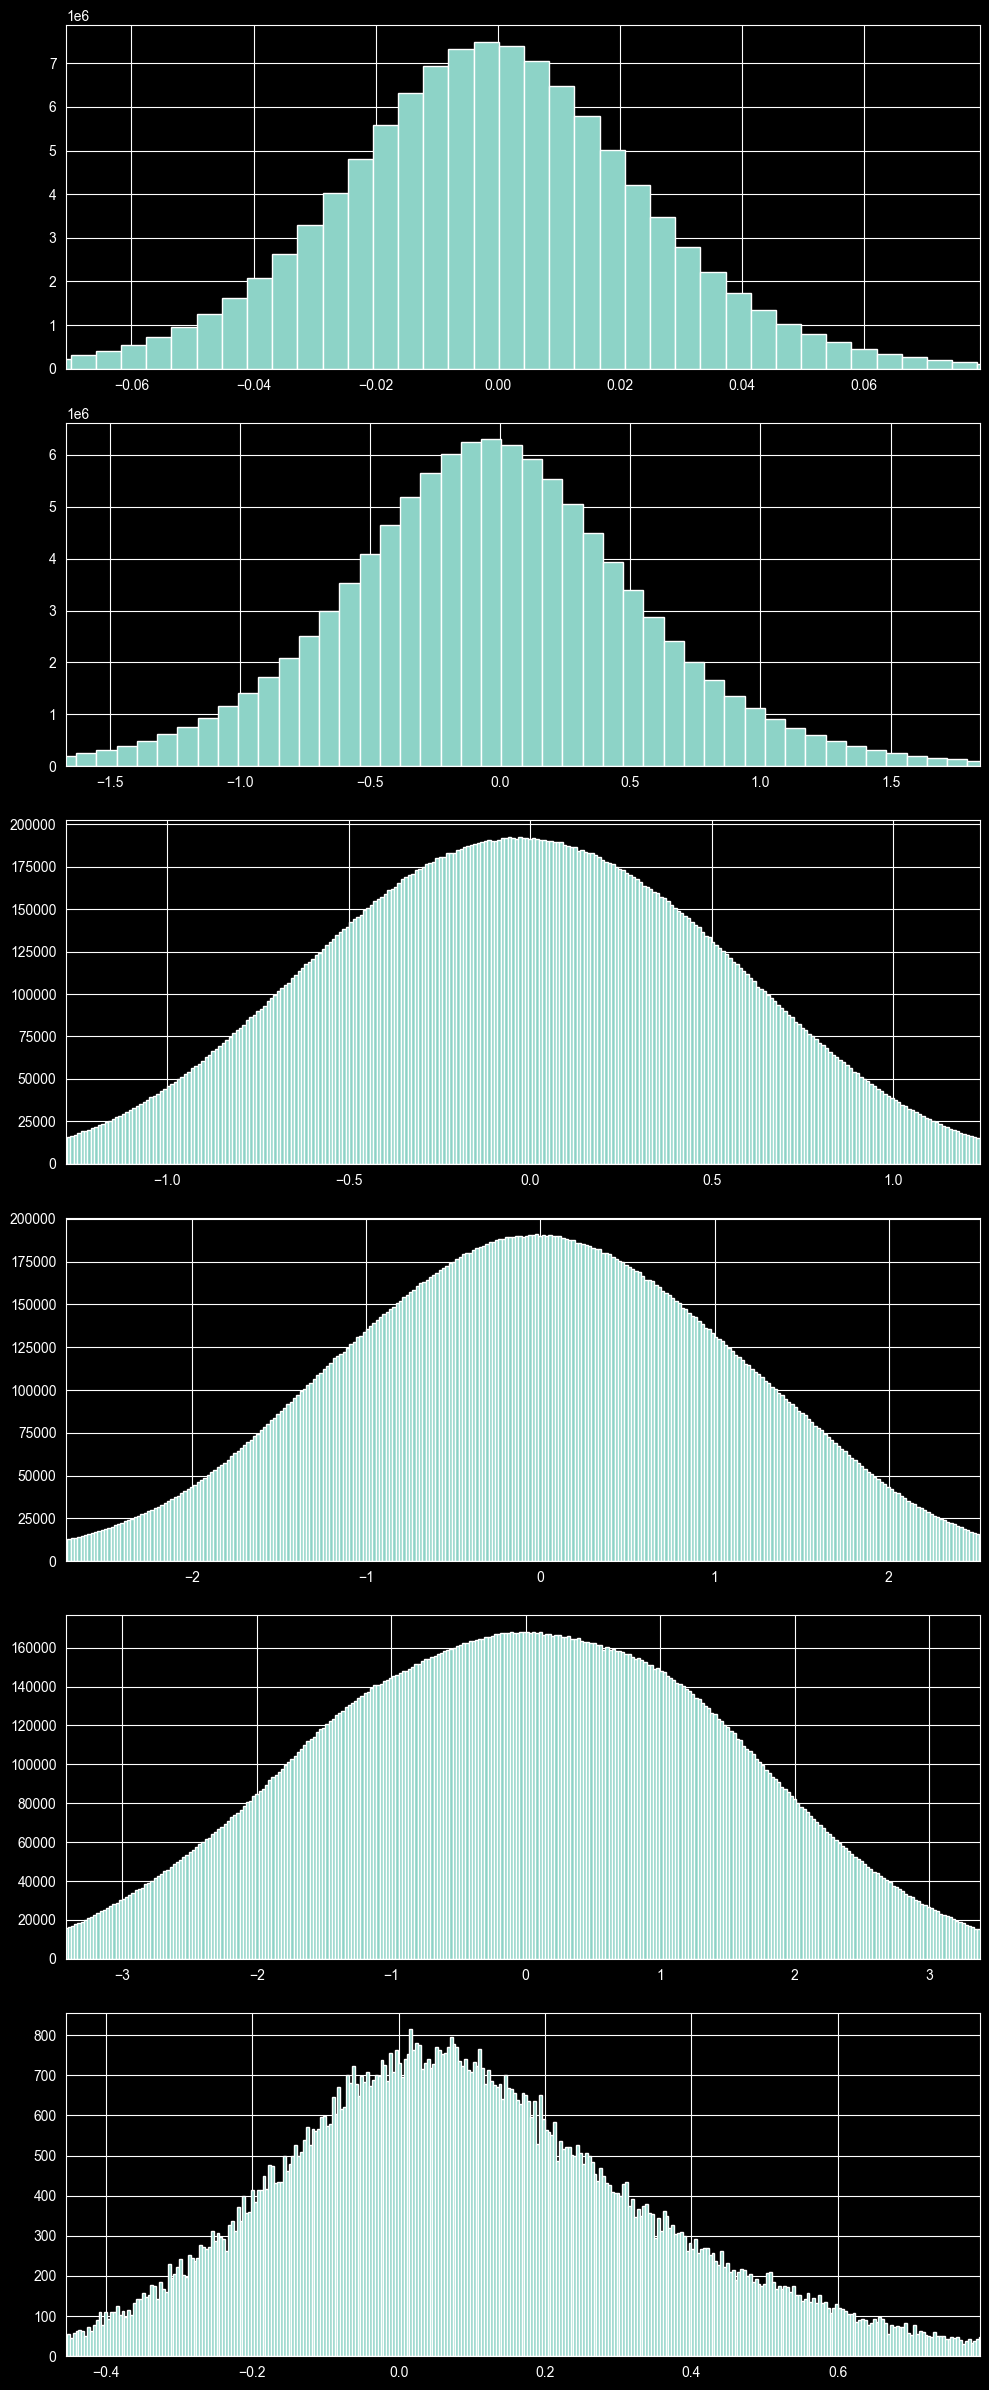

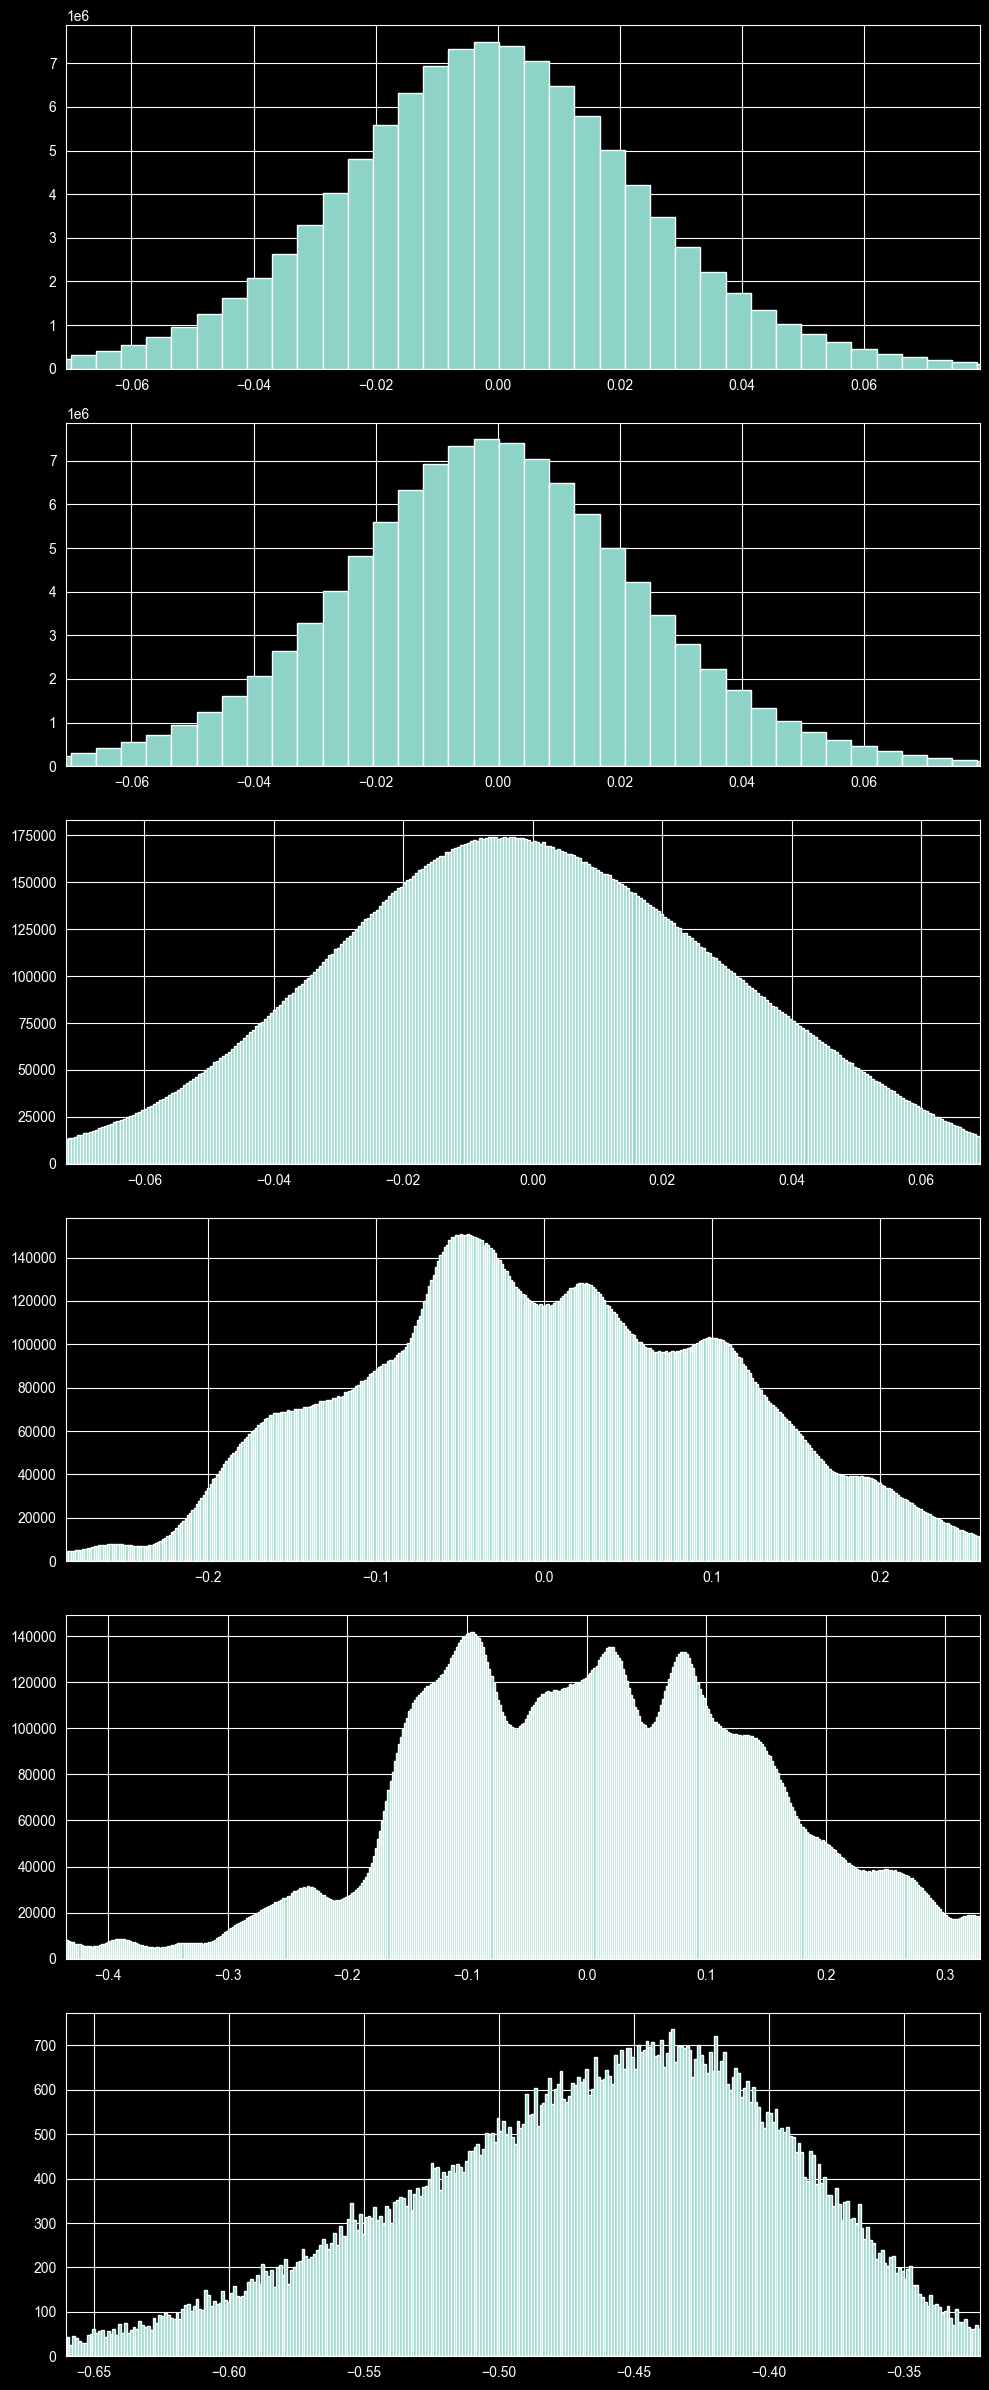

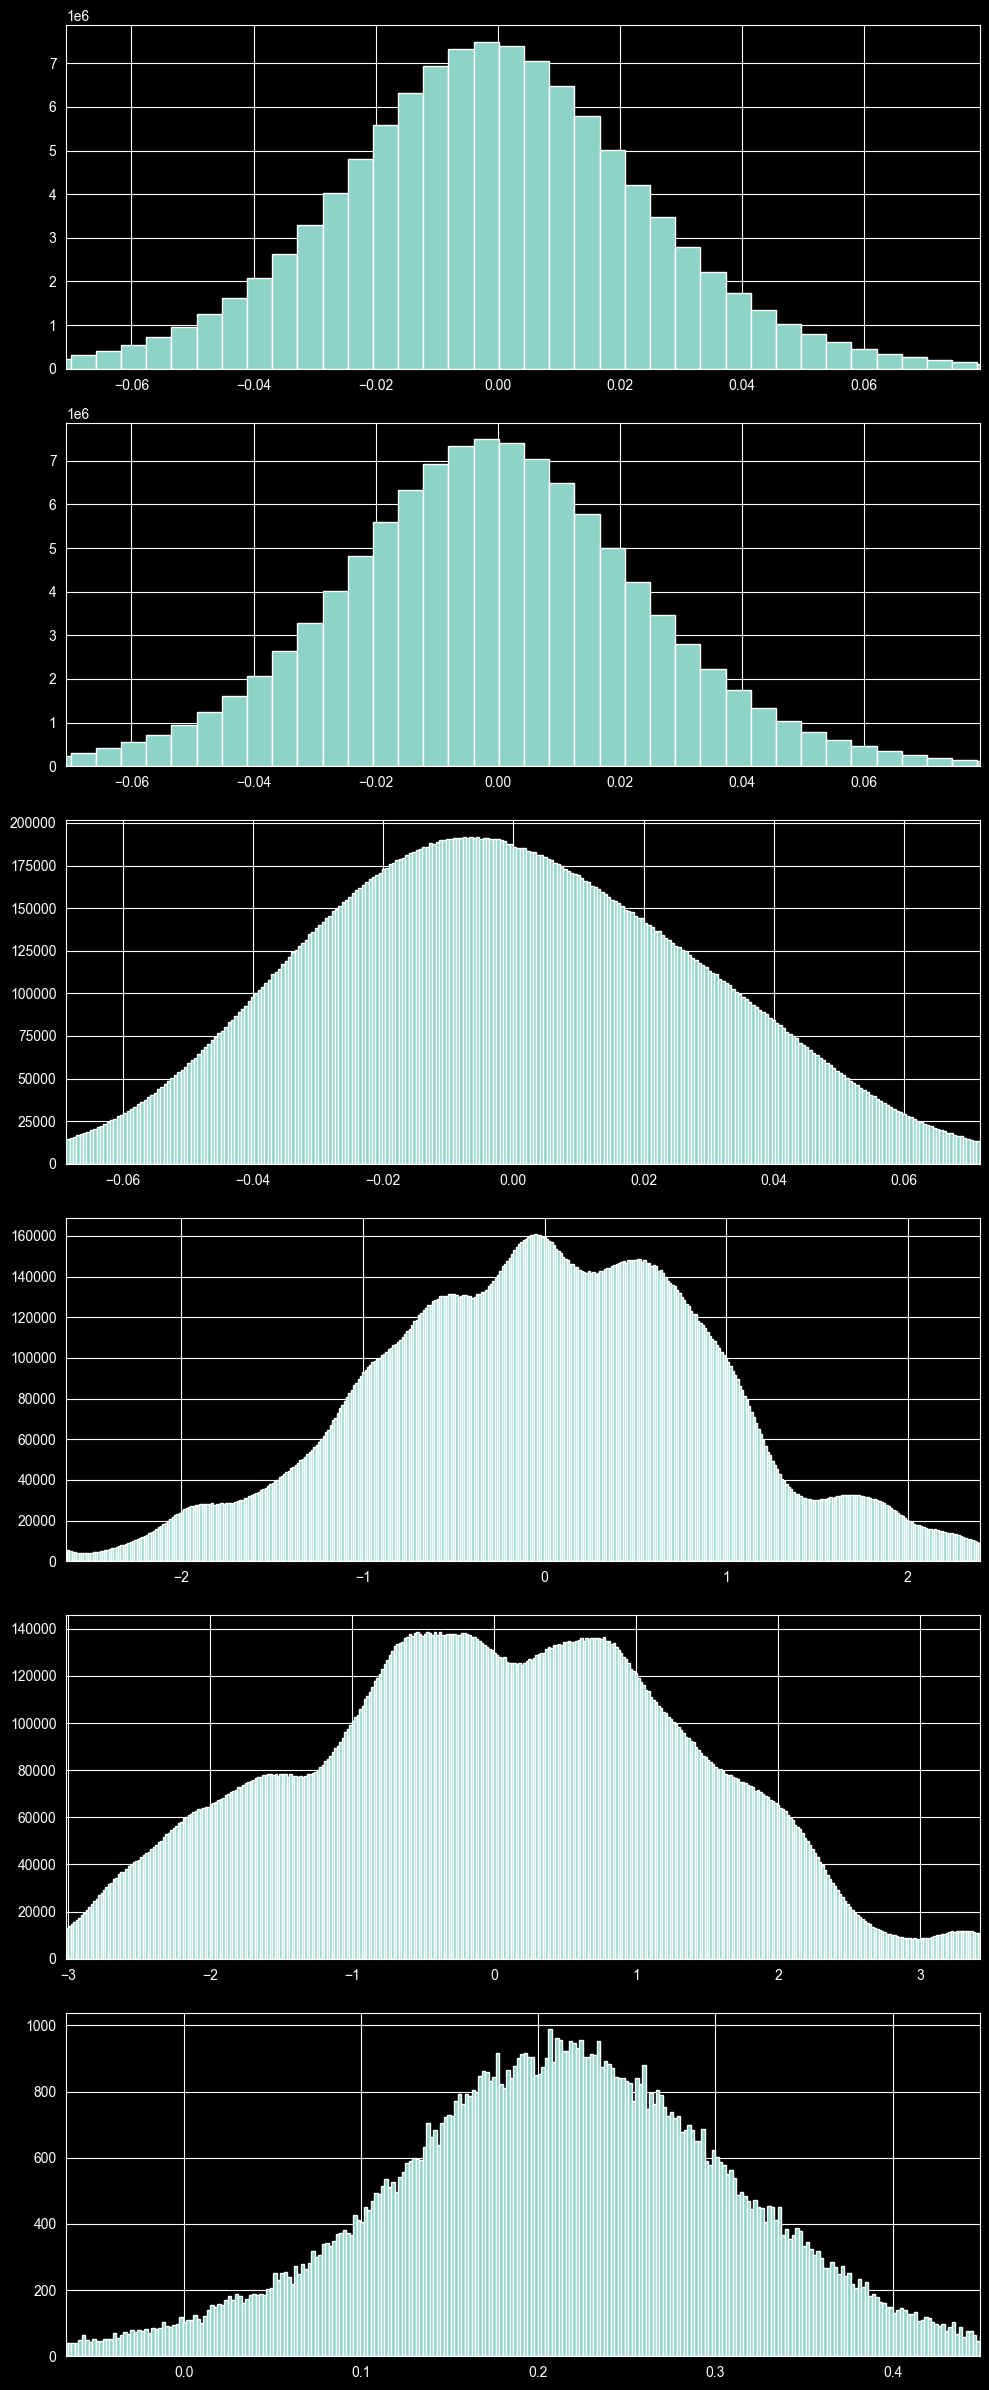

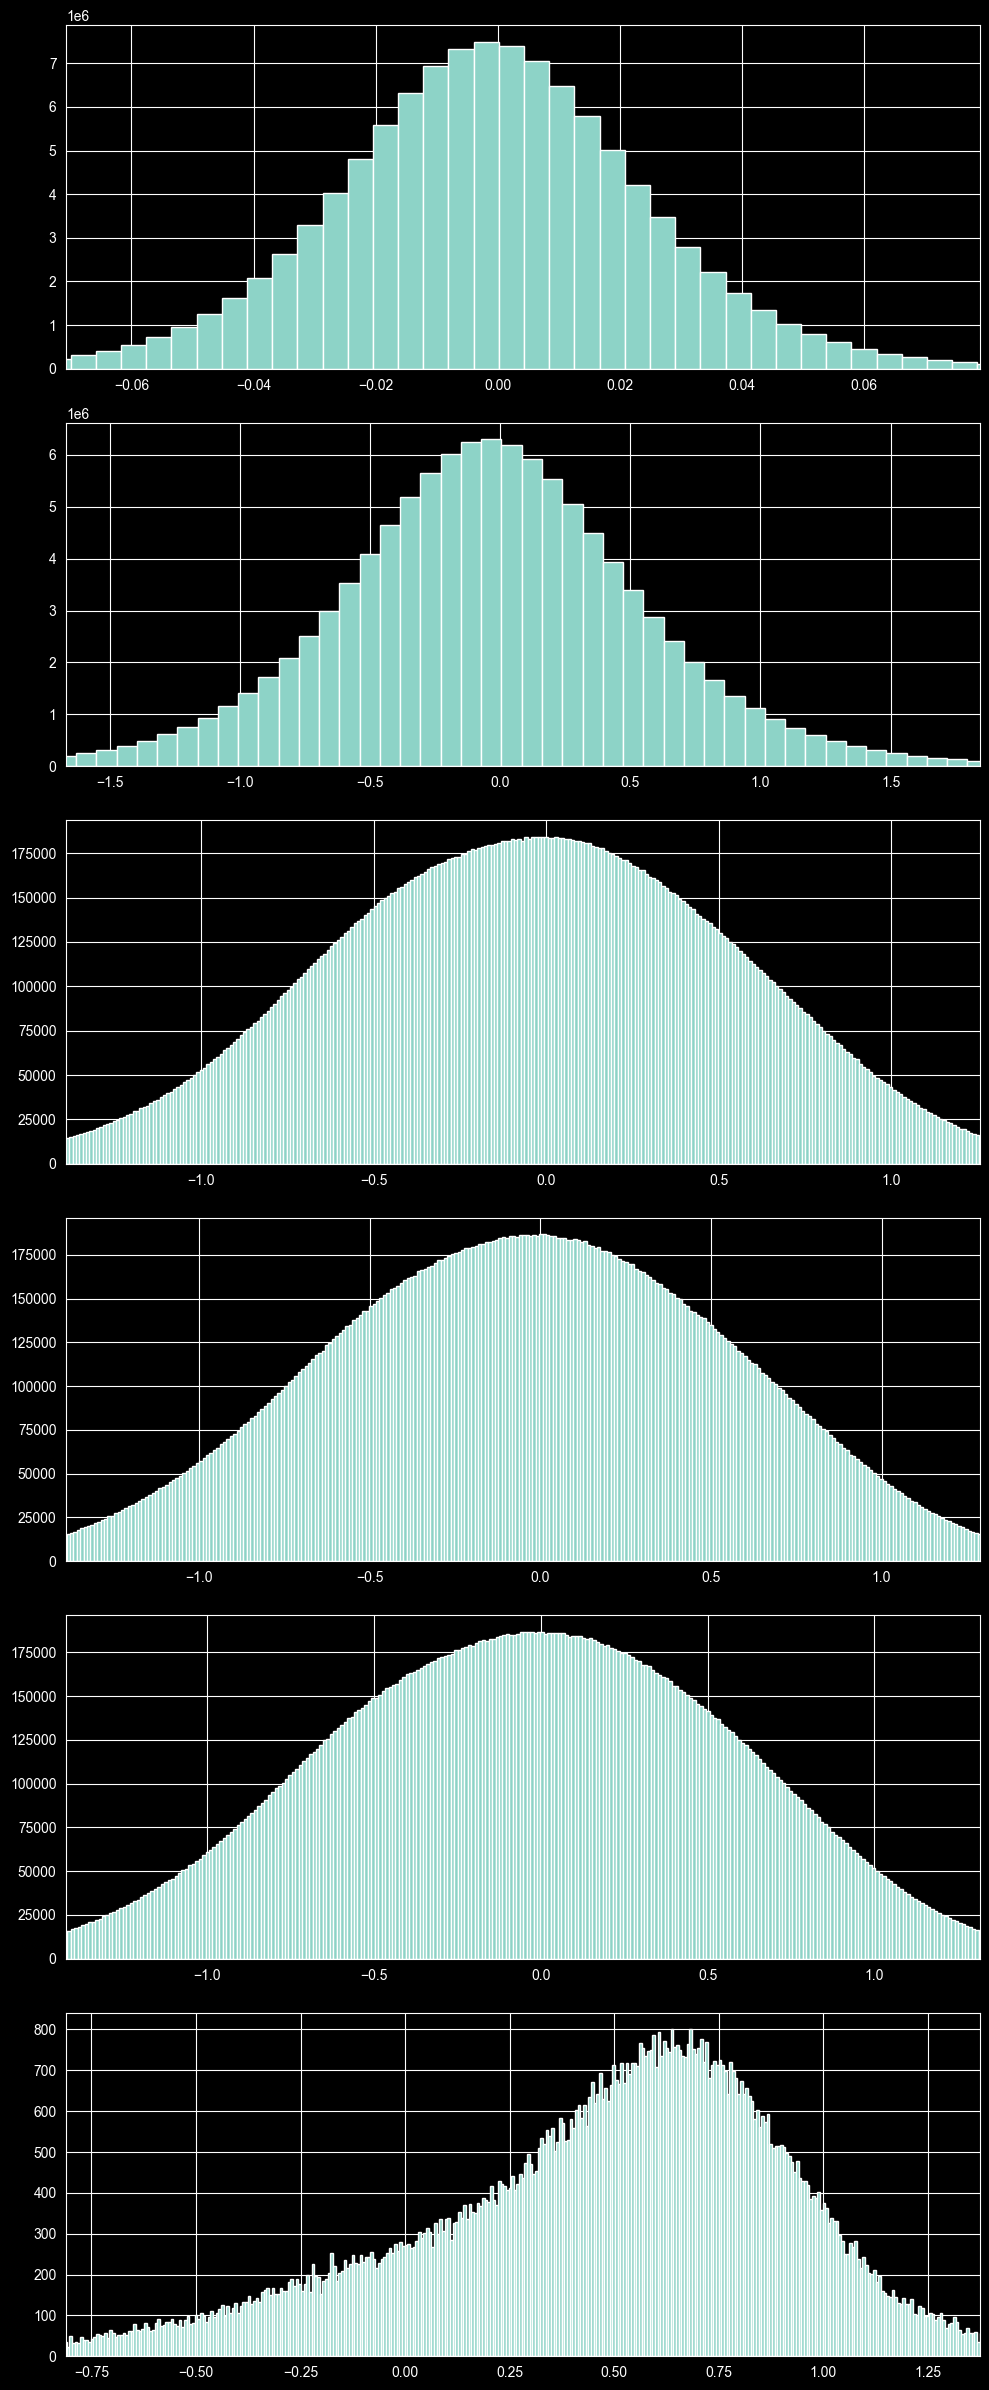

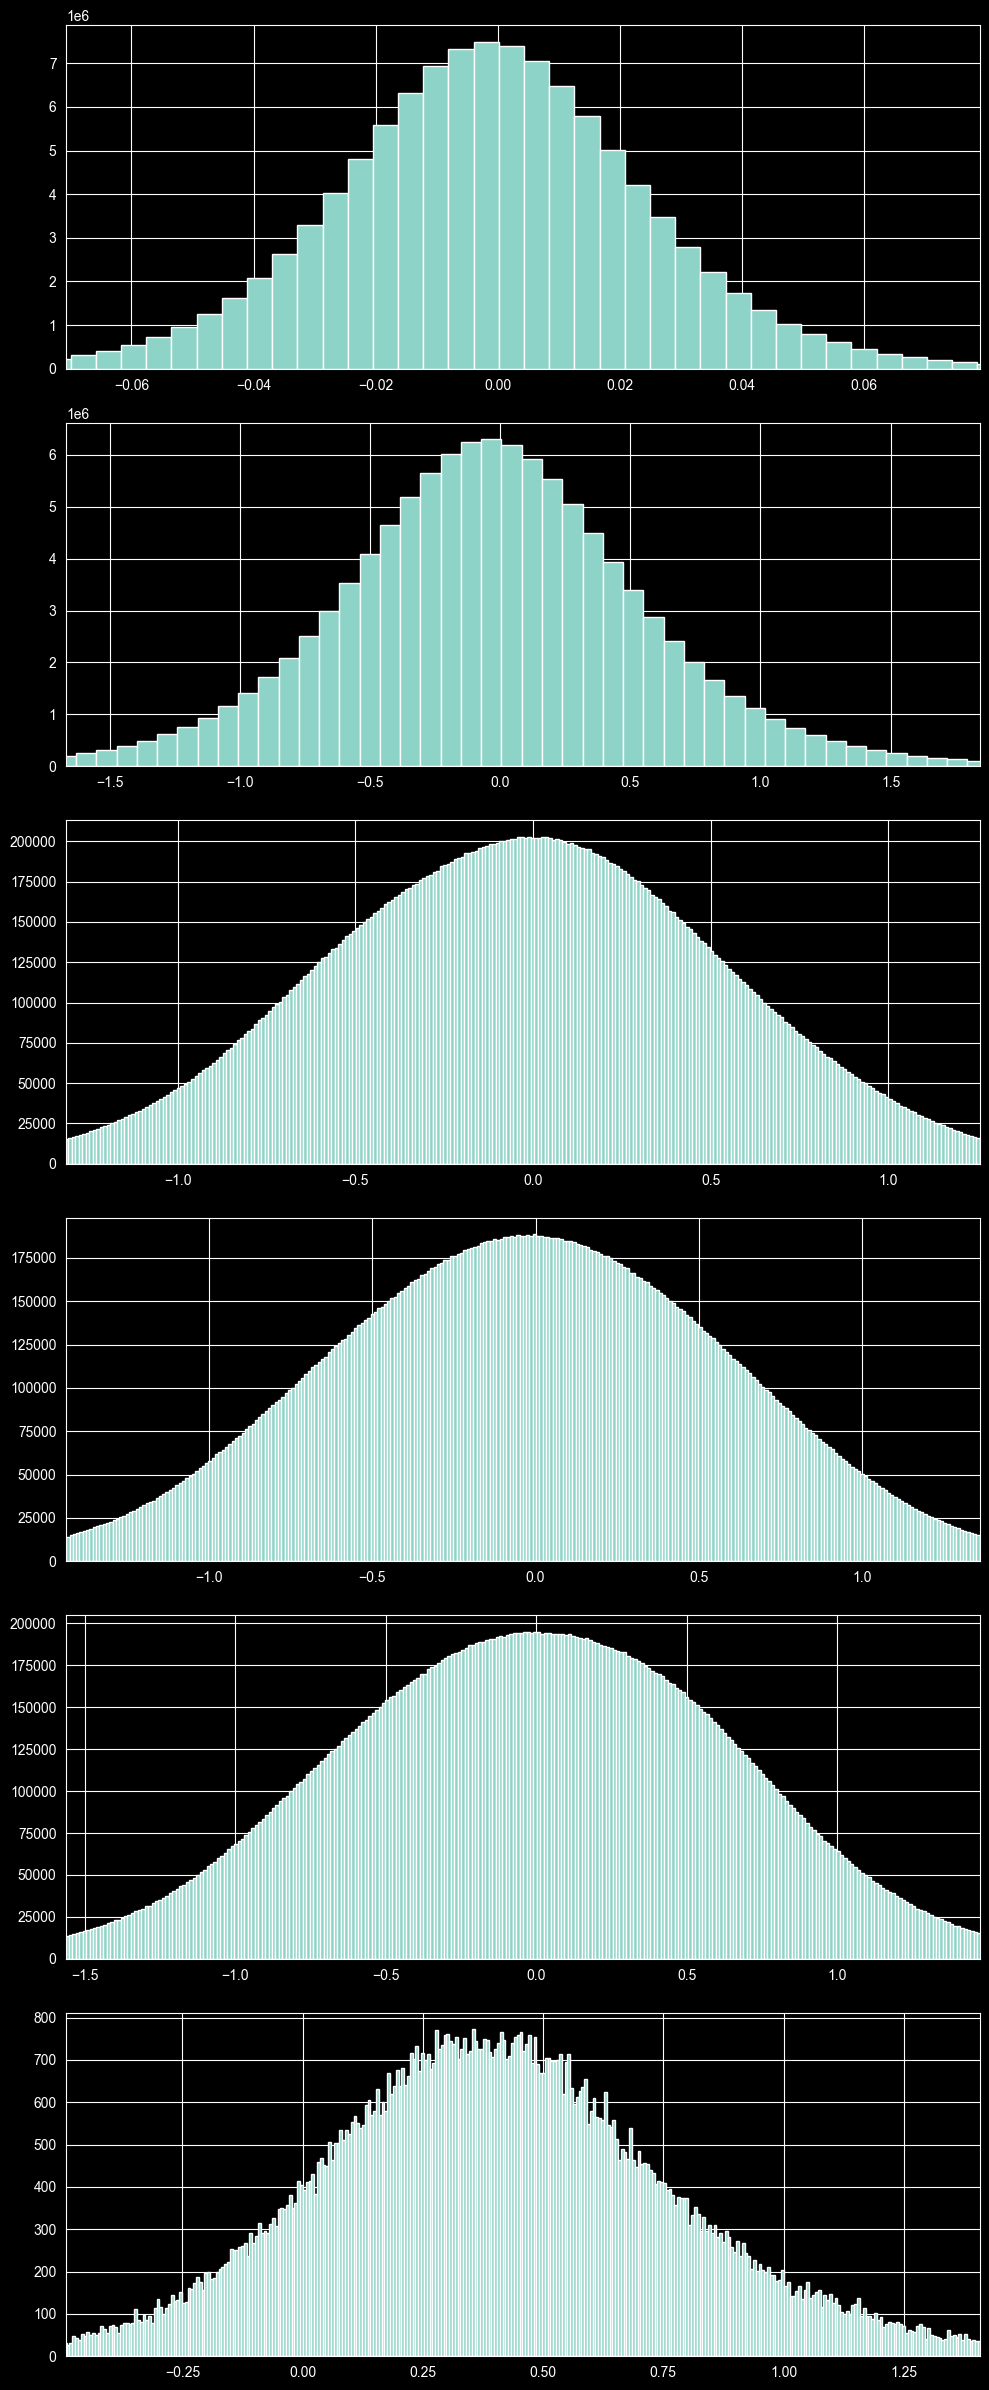

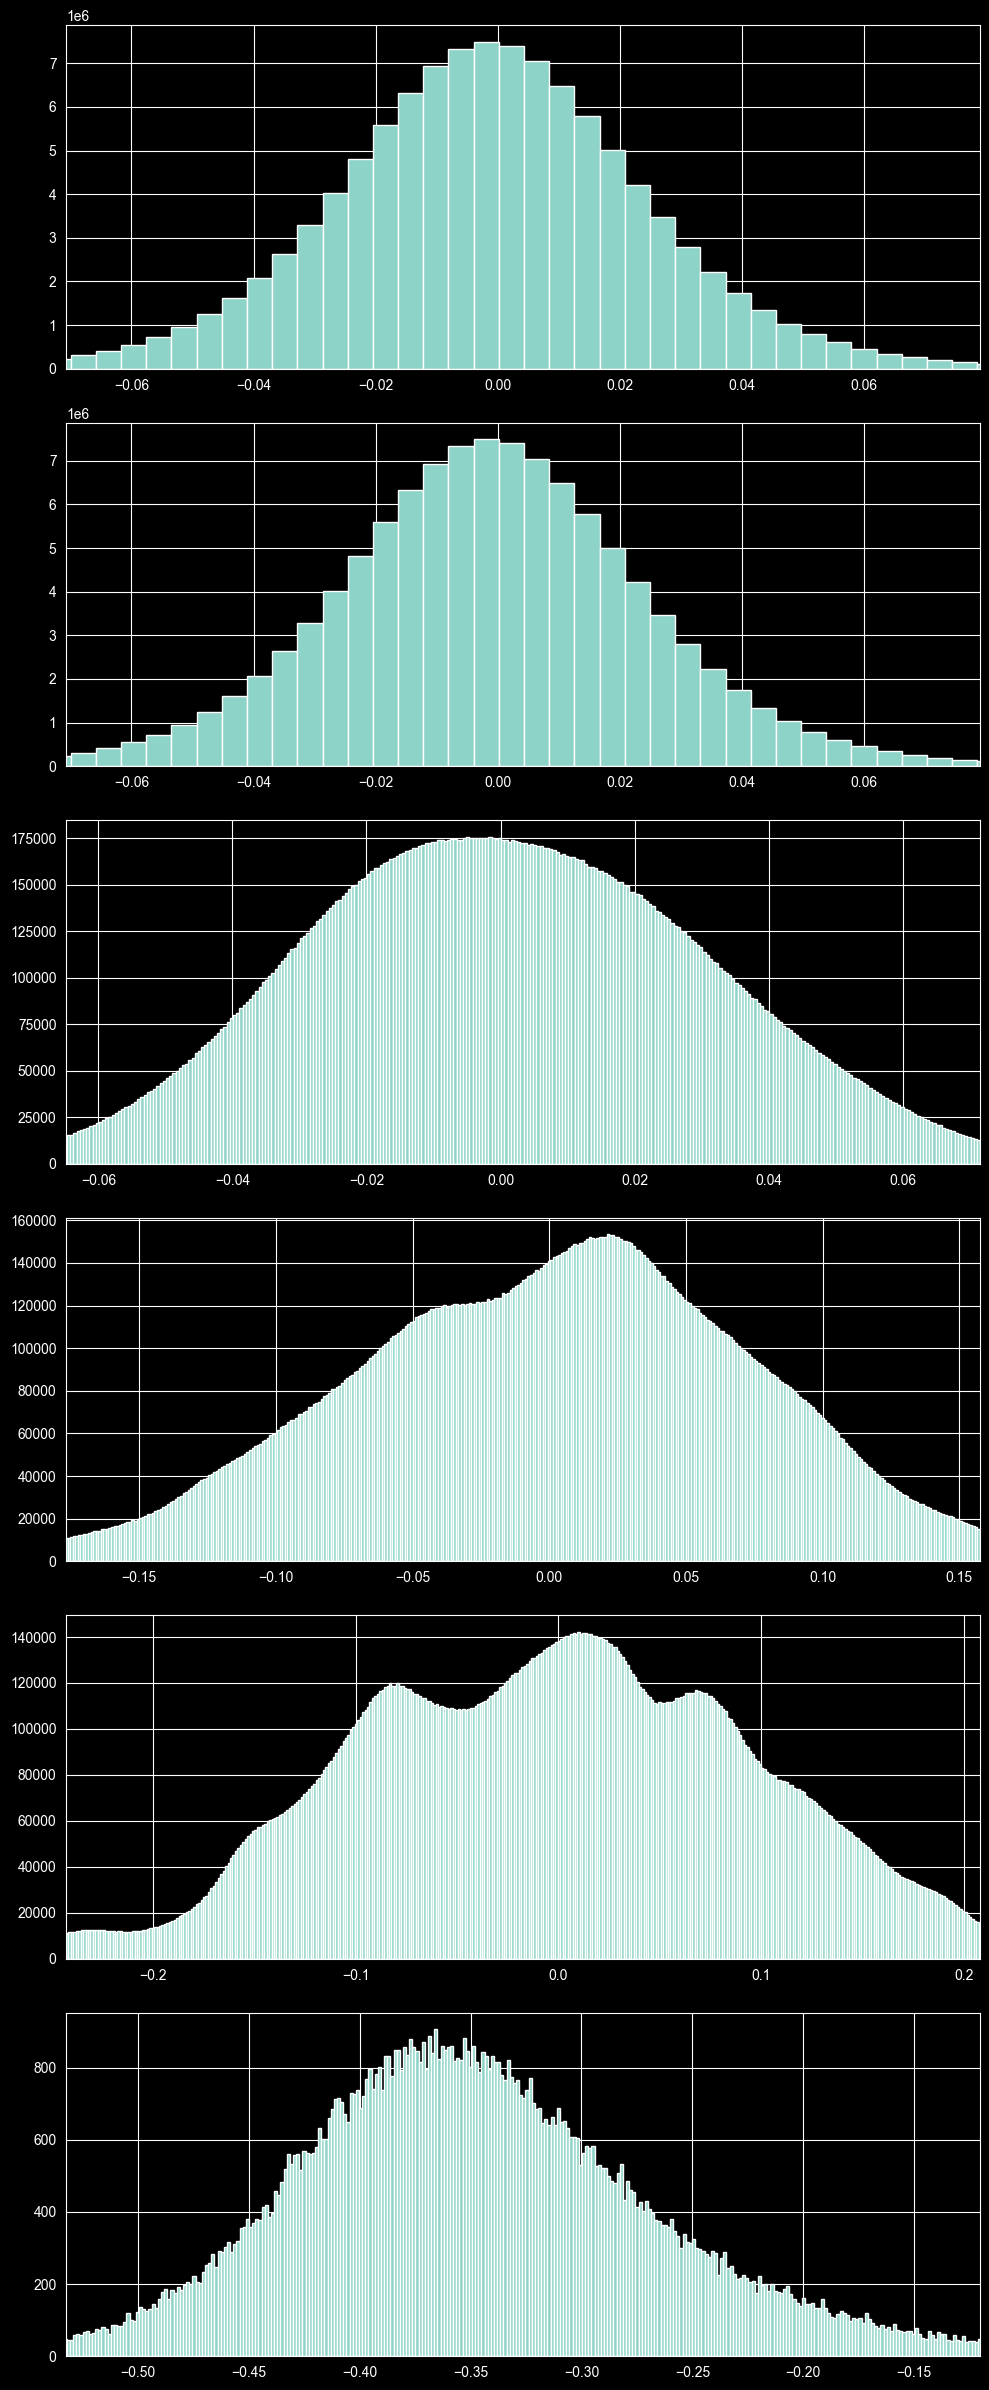

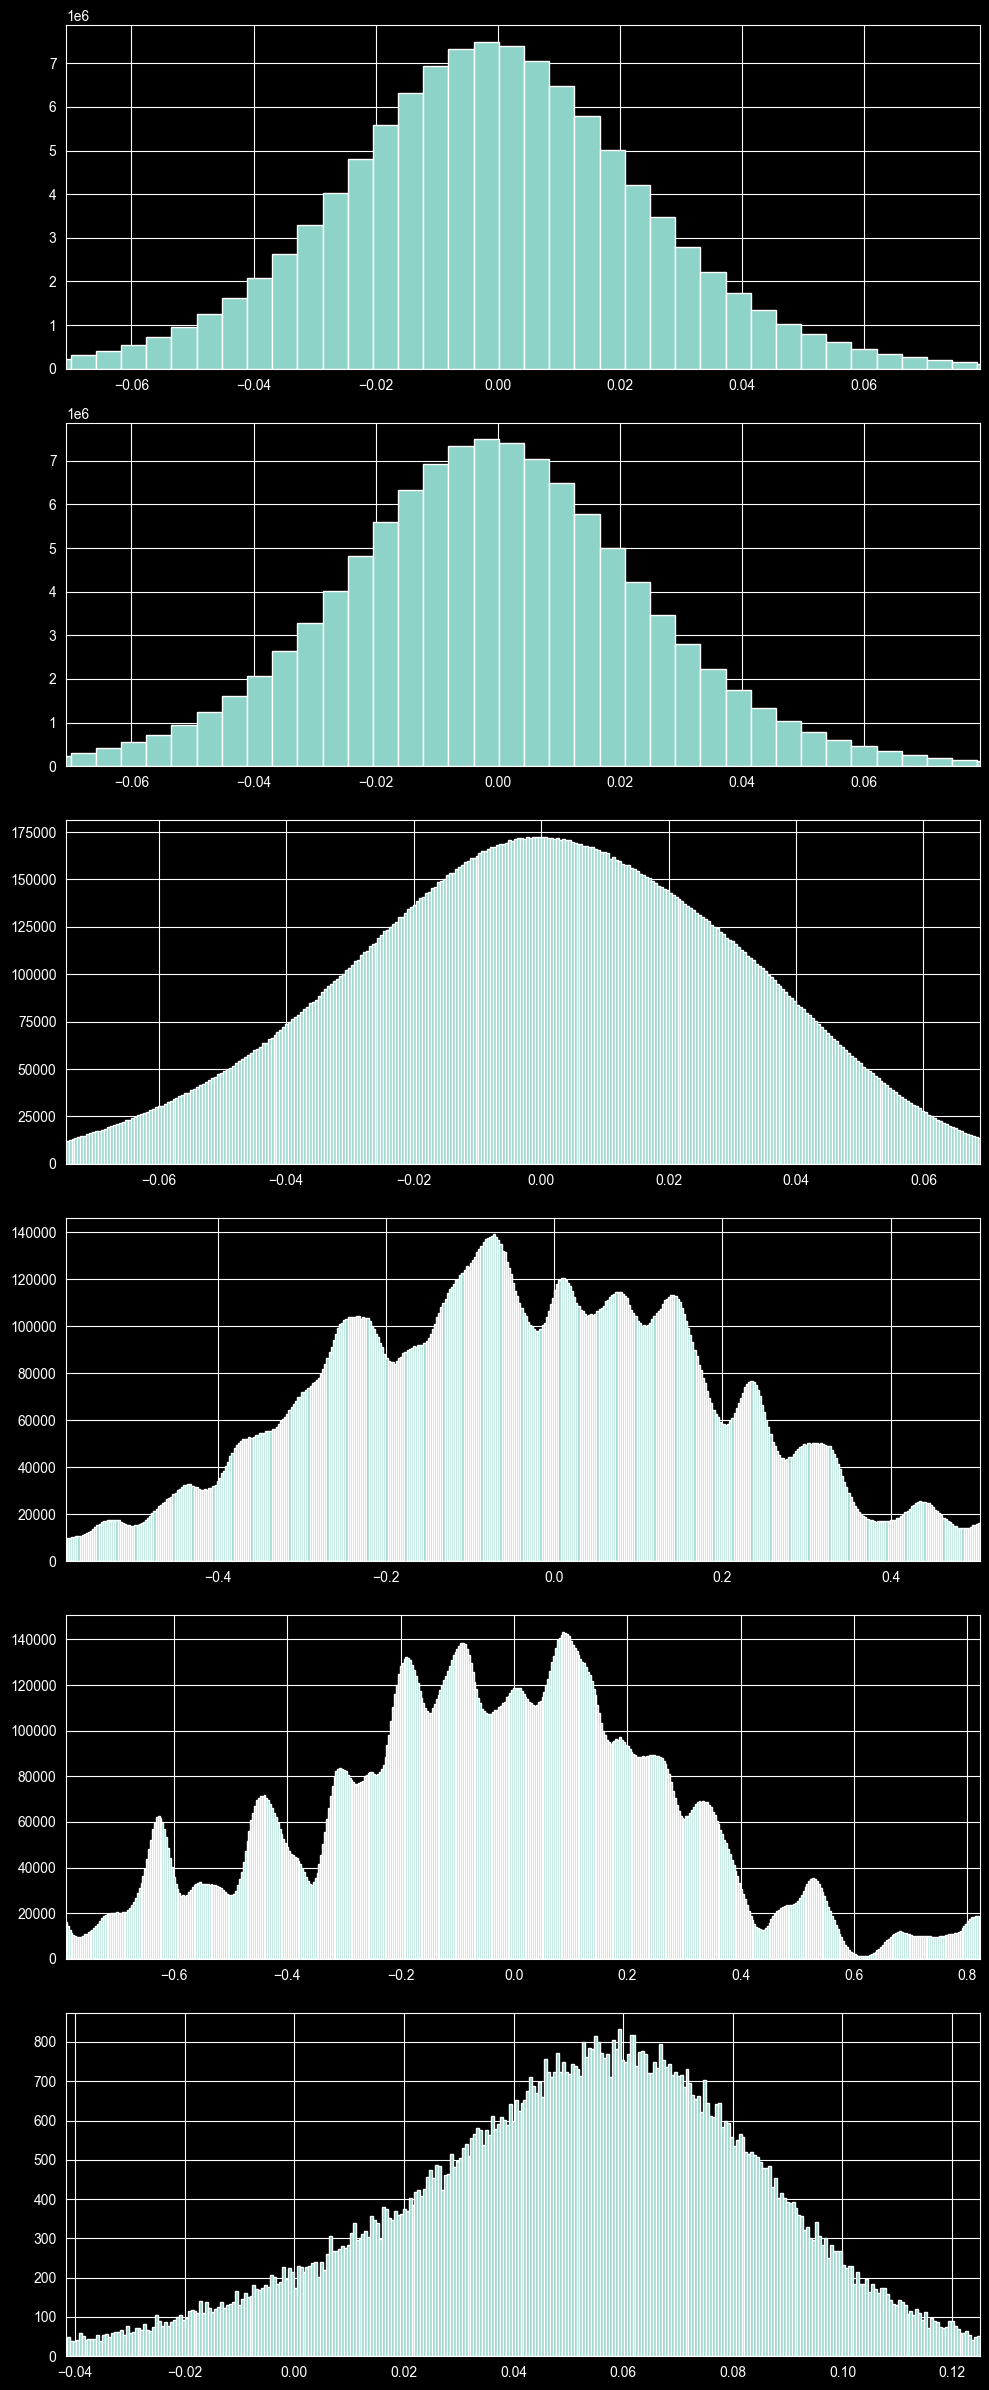

In [4]:
from itertools import product
testing = {
    'block_type': ['Conv1dInvBottleNeck', 'ConvNeXt1DBlock'],
    'inp_norm': [True, False],
    'batch_norm': [True, False]
}
combinations = list(product(*testing.values()))
combos_list = [dict(zip(testing.keys(), combo)) for combo in combinations]
for combo in combos_list:
    model = SequenceActiveSiteHead(
        dataset.embed_dim,
        hidden_dim=256,
        dropout=0.0,
        layers=2,
        **combo
    )
    model.to(device)
    model.eval()

    with torch.no_grad():
        x1 = model.inp_norm(inputs)
        x2 = model.stack.inp_proj(x1.transpose(1, 2))
        x3 = model.stack.stack[0](x2)
        x4 = model.stack.stack[1](x3)
        final = model(inputs)

    stored = []
    stored.append(apply_mask(inputs, mask))
    stored.append(apply_mask(x1, mask))
    stored.append(apply_mask(x2.transpose(1, 2), mask))
    stored.append(apply_mask(x3.transpose(1, 2), mask))
    stored.append(apply_mask(x4.transpose(1, 2), mask))
    stored.append(apply_mask(final.unsqueeze(-1), mask))

    name = f'BN:{combo['batch_norm']}, Norm{combo["inp_norm"]}, {combo['block_type'][4:10]}'
    hists(stored, bin=600, name=name)


